# Pleiades colour–magnitude outliers and Gaia RUWE

**Date:** 2026-07-31  
**Scientific question:** Are stars above the fitted single-star sequence more likely to have elevated RUWE?  
**Preserved source:** `../2026-07-31-gaia-pleiades-membership-distance/pleiades_members.csv`

Unresolved binaries can appear brighter than a single star of the same colour and can
      also disturb a single-source astrometric fit. Gaia's renormalised unit weight error (RUWE)
      is a fit-quality diagnostic, not a binary flag by itself. We fit a robust polynomial to
      the cluster colour–magnitude sequence and compare vertical residuals with RUWE.

      Crowding, variability, calibration, and the sequence fit also create outliers. The test
      therefore identifies candidates for follow-up, not confirmed companions. Changing the
      RUWE threshold checks how dependent the fraction is on a conventional cut.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
members=pd.read_csv("../2026-07-31-gaia-pleiades-membership-distance/pleiades_members.csv"); members=members[members.member.astype(bool)].copy()
members=members.dropna(subset=["parallax","parallax_error","pmra","pmdec","phot_g_mean_mag","bp_rp","ruwe"])
members["abs_g"]=members.phot_g_mean_mag+5*np.log10(members.parallax)-10
print(f"Preserved astrometric members: {len(members)}")

Preserved astrometric members: 609


In [3]:
fit=members[members.bp_rp.between(.2,3.2)&members.abs_g.between(-2,13)].copy(); coef=np.polyfit(fit.bp_rp,fit.abs_g,4); fit["sequence"]=np.polyval(coef,fit.bp_rp); fit["delta_g"]=fit.abs_g-fit.sequence
bright=fit.delta_g<-.45; elevated=fit.ruwe>1.2; table=pd.crosstab(bright,elevated); odds,pvalue=stats.fisher_exact(table); print(table); print(f"odds ratio={odds:.2f}, p={pvalue:.3g}")

ruwe     False  True 
delta_g              
False      406     26
True        27      7
odds ratio=4.05, p=0.00632


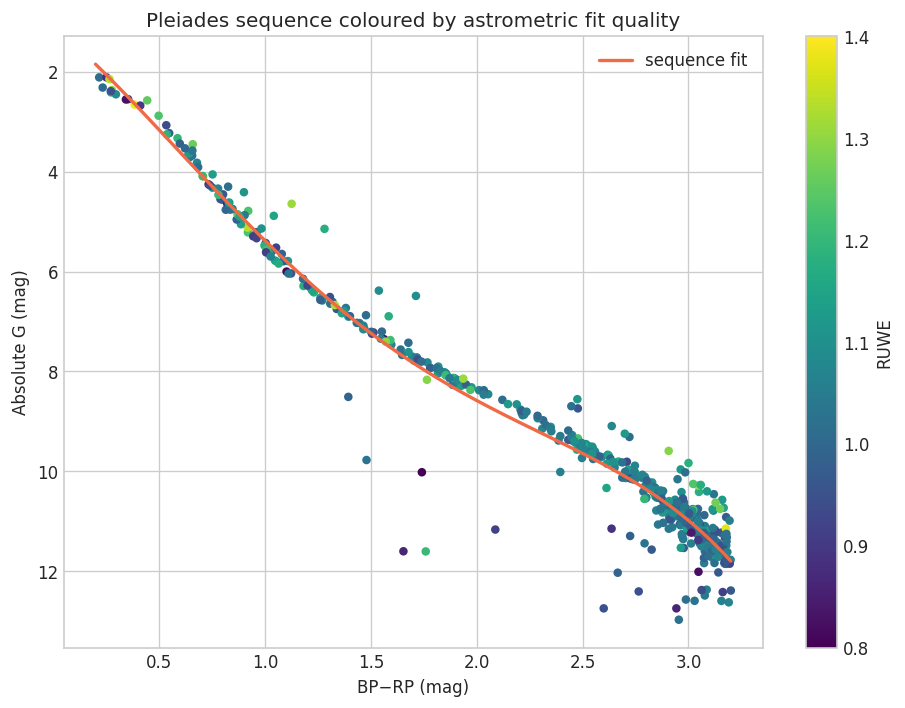

In [4]:
fig,ax=plt.subplots(figsize=(8,6)); sc=ax.scatter(fit.bp_rp,fit.abs_g,c=fit.ruwe,s=17,cmap="viridis",vmin=.8,vmax=1.4); x=np.linspace(.2,3.2,300); ax.plot(x,np.polyval(coef,x),color=COLORS["orange"],lw=2,label="sequence fit"); ax.invert_yaxis(); ax.set(xlabel="BP−RP (mag)",ylabel="Absolute G (mag)",title="Pleiades sequence coloured by astrometric fit quality"); ax.legend(); plt.colorbar(sc,ax=ax,label="RUWE"); fig.tight_layout(); fig.savefig("pleiades_cmd_ruwe.png",dpi=180); plt.show()

In [5]:
elevated_alt=fit.ruwe>1.1; table_alt=pd.crosstab(bright,elevated_alt); odds_alt,p_alt=stats.fisher_exact(table_alt); print(f"RUWE>1.1 odds ratio={odds_alt:.2f}, p={p_alt:.3g}")

RUWE>1.1 odds ratio=5.58, p=3.07e-06


In [6]:
result={"id":"2026-07-31-pleiades-cmd-ruwe-binaries","title":"Pleiades CMD outliers and RUWE","archive":"Gaia DR3","date":"2026-07-31","question":"Do over-luminous candidates have elevated RUWE more often?","sample_size":int(len(fit)),"results":[f"RUWE>1.2 odds ratio {odds:.2f}",f"Fisher-test p = {pvalue:.3g}",f"RUWE>1.1 odds ratio {odds_alt:.2f}"],"validation":"The contingency test is repeated at RUWE thresholds 1.2 and 1.1.","notebook":"gaia/2026-07-31-pleiades-cmd-ruwe-binaries/notebook.ipynb","hero":"gaia/2026-07-31-pleiades-cmd-ruwe-binaries/pleiades_cmd_ruwe.png","tags":["Pleiades","RUWE","binary candidates"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['RUWE>1.2 odds ratio 4.05', 'Fisher-test p = 0.00632', 'RUWE>1.1 odds ratio 5.58']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- ESA Gaia Archive: https://gea.esac.esa.int/archive/
- Gaia Collaboration (2023), Gaia Data Release 3 summary: https://doi.org/10.1051/0004-6361/202243940
- Lindegren et al. (2021), Gaia EDR3 astrometric solution: https://arxiv.org/abs/2012.03380
- Gaia Collaboration (2018), cluster kinematics and dynamics: https://arxiv.org/abs/1804.09378

Formal catalogue errors do not include every spatially correlated systematic.
The deconvolved cluster widths are therefore conservative diagnostics.